## Predicción de precios de casas: regresión con redes neuronales



## Carga del Dataset

El dataset que vamos a utilizar se puede bajar de [kaggle](https://www.kaggle.com/harlfoxem/housesalesprediction?select=kc_house_data.csv).



## Características del Dataset

* Este conjunto de datos contiene precios de venta de casas para el condado de King, que incluye a Seattle.
* Incluye viviendas vendidas entre mayo de 2014 y mayo de 2015.
* 21 columnas. (features)
* 21597 filas (registros).

***Features***
    
* **id:** Identificación única para cada casa vendida
* **date:** Fecha de la venta de la casa
* **price:** Precio con que se vendió la propiedad
* **bedrooms:** Numero de habitaciones
* **bathrooms:** Número de baños, donde 0.5 representa una habitación con inodoro pero sin ducha
* **sqft_living:** Pies cuadrados del espacio habitable interior de la casa
* **sqft_lot:** Pies cuadrados del terreno
* **floors:** número de plantas
* **waterfront:** - Una variable categórica para determinar si la casa tenía vistas al paseo marítimo o no.
* **view:** Un índice de 0 a 4 indicando qué tan buena es la vista de la propiedad
* **condition:** Un índice del 1 al 5 sobre el estado de la casa
* **grade:** Un índice del 1 al 13, donde 1-3 indica bajo, 7 medio y 11-13 alto nivel de calidad de construcción y diseño.
* **sqft_above:** Los pies cuadrados del espacio interior de la vivienda que está sobre el nivel del suelo
* **sqft_basement:** Los pies cuadrados del espacio interior de la vivienda que está por debajo del nivel del suelo
* **yr_built:** El año en que se construyó inicialmente la casa.
* **yr_renovated:** El año de la última reforma de la casa.
* **zipcode:** código postal de la casa
* **lat:** Latitud
* **long:** Longitud
* **sqft_living15:** Los pies cuadrados de espacio habitable de vivienda interior para los 15 vecinos más cercanos
* **sqft_lot15:** Los metros cuadrados de los terrenos de los 15 vecinos más cercanos

In [ ]:
# data analysis and wrangling
import pandas as pd
import numpy as np
import random as rnd

# visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# scaling and train test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# creating a model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import Adam

# evaluation on test data
from sklearn.metrics import mean_squared_error,mean_absolute_error,explained_variance_score
from sklearn.metrics import classification_report,confusion_matrix



## Análisis de datos.

Primero cargamos el dataset en drive en un directorio (path_csv) y montamos drive en la notebook.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
path_csv = '/content/drive/MyDrive/kc_house_data.csv'
house_df = pd.read_csv(path_csv)  # cargamos el dataset en un pandas dataframe: house_df

In [ ]:
house_df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
house_df.shape

(21613, 21)

In [ ]:
house_df.count()

id               21613
date             21613
price            21613
bedrooms         21613
bathrooms        21613
sqft_living      21613
sqft_lot         21613
floors           21613
waterfront       21613
view             21613
condition        21613
grade            21613
sqft_above       21613
sqft_basement    21613
yr_built         21613
yr_renovated     21613
zipcode          21613
lat              21613
long             21613
sqft_living15    21613
sqft_lot15       21613
dtype: int64

In [ ]:
house_df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [ ]:
house_df.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

Lo que importa es la antigüedad. Para obtener esto, primero agregamos una columna para el año de venta (lo sacamos de los primeros dígitos de 'date')

In [ ]:
house_df['reg_year'] = house_df['date'].str[:4]  # str[:4] toma los primeros 4 caracteres (año)
print(house_df['reg_year']) #check

0        2014
1        2014
2        2015
3        2014
4        2015
         ... 
21608    2014
21609    2015
21610    2014
21611    2015
21612    2014
Name: reg_year, Length: 21613, dtype: object


como es tipo objeto lo convertimos a integer

In [ ]:
house_df['reg_year'] = house_df['reg_year'].astype('int')

In [ ]:
house_df.dtypes  #check

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
reg_year           int64
dtype: object

In [ ]:
# agregamos una columna 'house_age' con Nan
import numpy as np
house_df['house_age'] = np.NaN

In [ ]:
# loop a través de la columna de renovación para encontrar antigüedad de la casa:
for i, j in enumerate(house_df['yr_renovated']):
  if (j==0): # nunca fué renovada
    house_df['house_age'][i] = house_df['reg_year'][i] - house_df['yr_built'][i] # (año de venta - año de construcción)
  else:
    house_df['house_age'][i] = house_df['reg_year'][i] - house_df['yr_renovated'][i] # (año de venta - año de renovación)


Se truncaron las últimas líneas 5000 del resultado de transmisión.
<ipython-input-52-d0e2217386bb>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  house_df['house_age'][i] = house_df['reg_year'][i] - house_df['yr_built'][i] # (año de venta - año de construcción)
<ipython-input-52-d0e2217386bb>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  house_df['house_age'][i] = house_df['reg_year'][i] - house_df['yr_built'][i] # (año de venta - año de construcción)
<ipython-input-52-d0e2217386bb>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: 

In [ ]:
house_df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,reg_year,house_age
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,59.0
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,23.0
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,82.0
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,49.0
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,28.0


El data set contiene latitud y longitud. Estas son magnitudes que permiten visualizar geográficamente los datos. Para ello utilizaremos [seaborn](https://seaborn.pydata.org/).


<Axes: xlabel='long', ylabel='lat'>

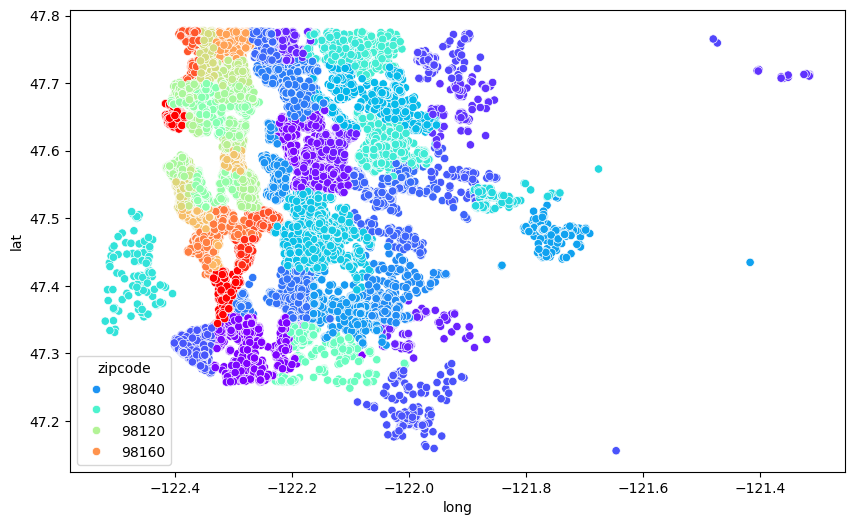

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=house_df, x='long', y='lat', hue='zipcode',palette='rainbow') # mapa de casas por zipcode

Distribución geográfica por precio:


<Axes: xlabel='long', ylabel='lat'>

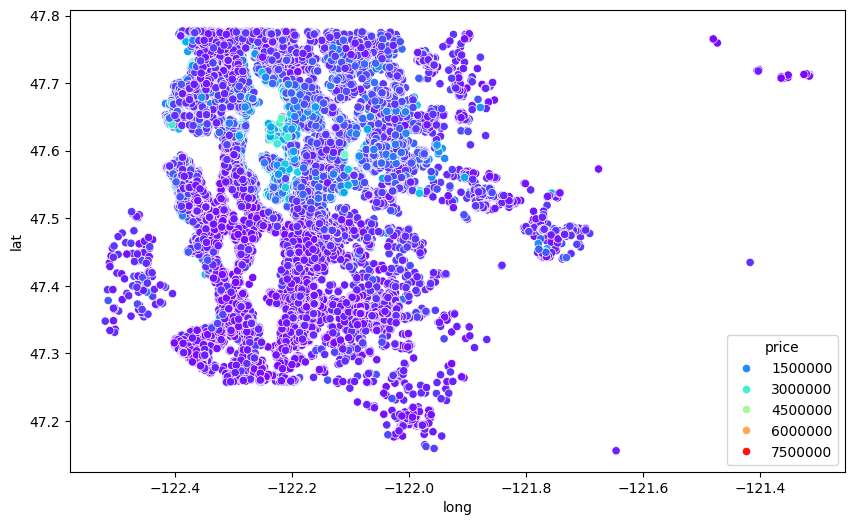

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=house_df, x='long', y='lat', hue='price', palette='rainbow')
# mapa de casas por precio

Ahora armamos una copia eliminando todas las columnas de id, zipcode y fechas y nos quedamos con la antigüedad solamente:

In [ ]:

house_dfl = house_df.drop(['id','zipcode','date','yr_built','yr_renovated','reg_year'], axis=1,)
house_dfl.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,lat,long,sqft_living15,sqft_lot15,house_age
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,47.5112,-122.257,1340,5650,59.0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,47.7210,-122.319,1690,7639,23.0
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,47.7379,-122.233,2720,8062,82.0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,47.5208,-122.393,1360,5000,49.0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,47.6168,-122.045,1800,7503,28.0


In [ ]:
house_dfl.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,lat,long,sqft_living15,sqft_lot15,house_age
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,47.560053,-122.213896,1986.552492,12768.455652,40.936936
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,0.138564,0.140828,685.391304,27304.179631,28.813643
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,47.155900,-122.519000,399.000000,651.000000,-1.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,47.471000,-122.328000,1490.000000,5100.000000,15.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,47.571800,-122.230000,1840.000000,7620.000000,37.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,47.678000,-122.125000,2360.000000,10083.000000,60.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,47.777600,-121.315000,6210.000000,871200.000000,115.000000


Observamos que hay casas con antigüedad -1, lo cual es extraño, aún así continuamos el analisis sin modificar el dataset.

###Histogramas.
Podemos visualizar histogramas (de una cantidad o del conjunto)

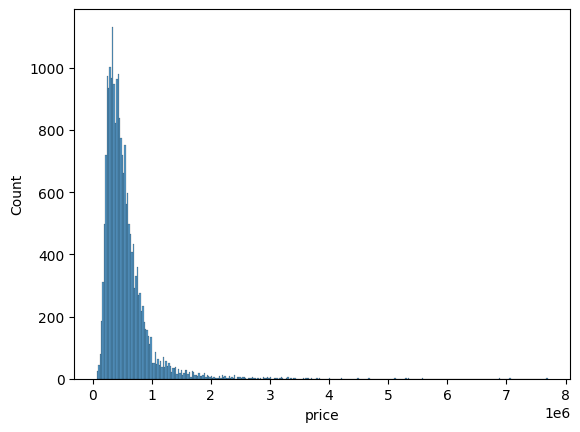

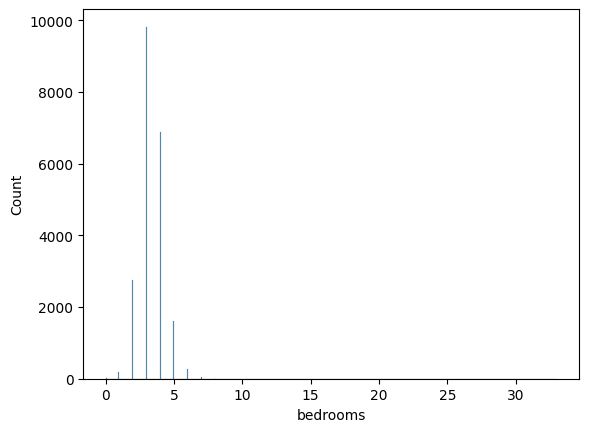

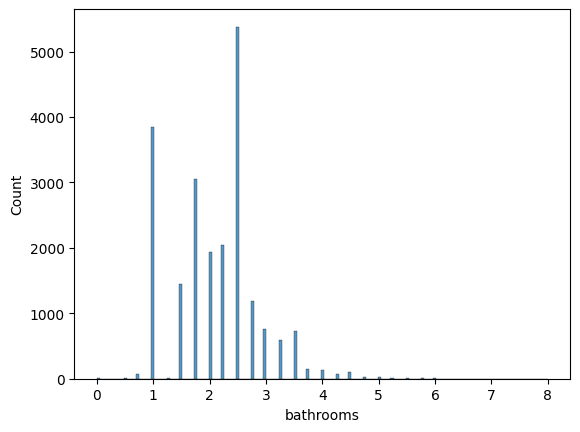

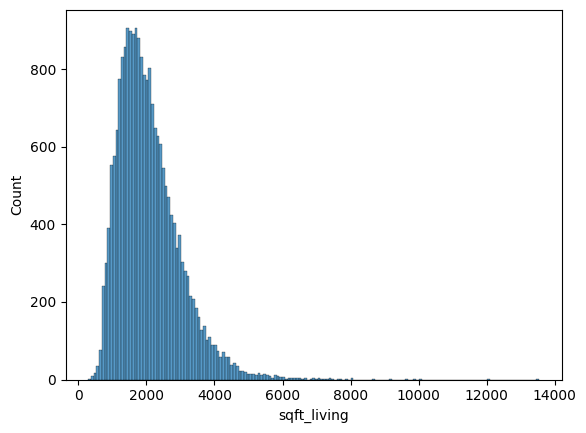

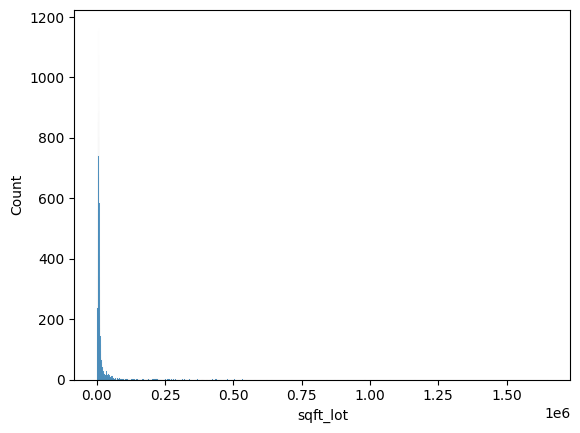

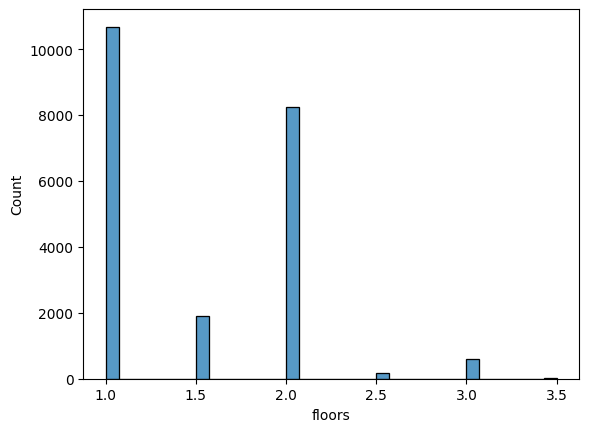

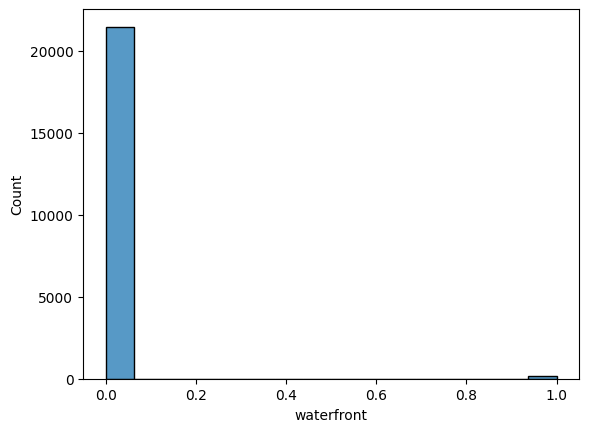

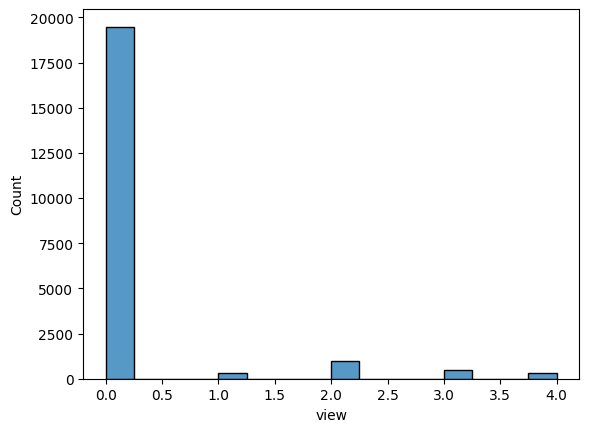

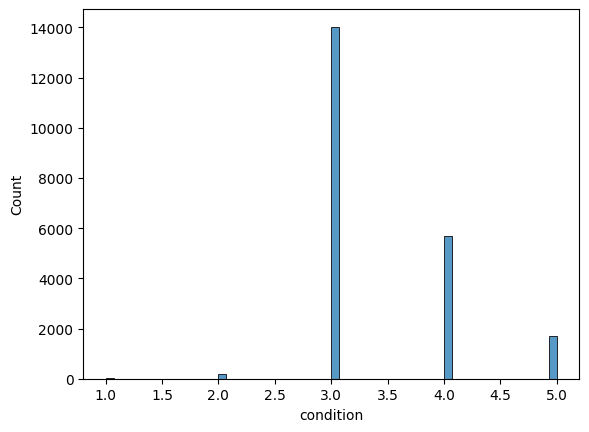

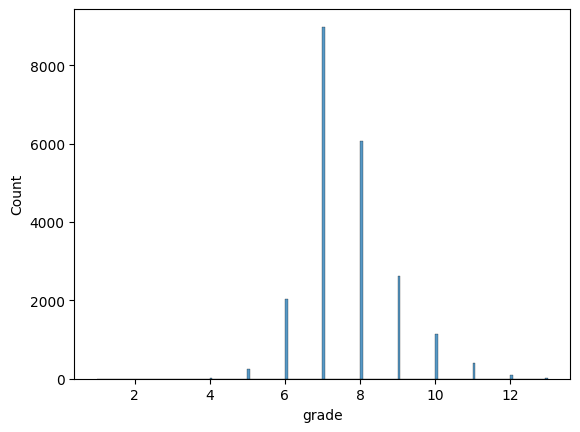

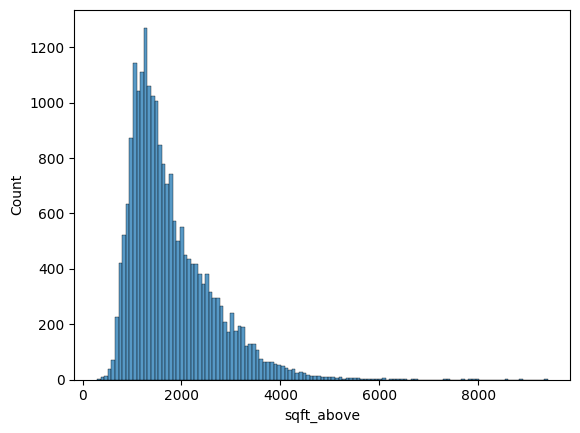

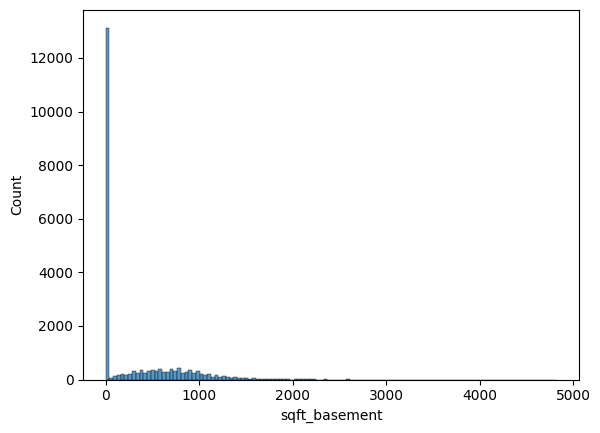

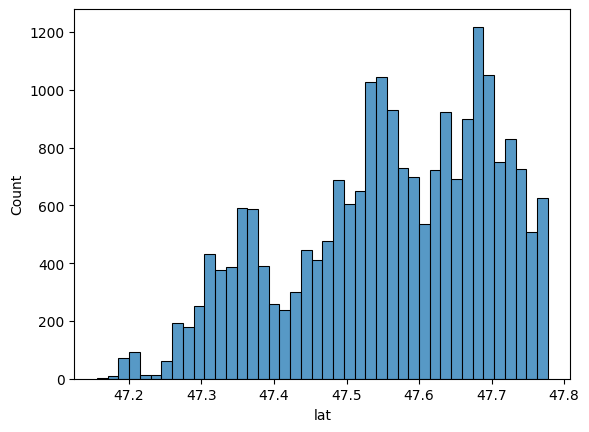

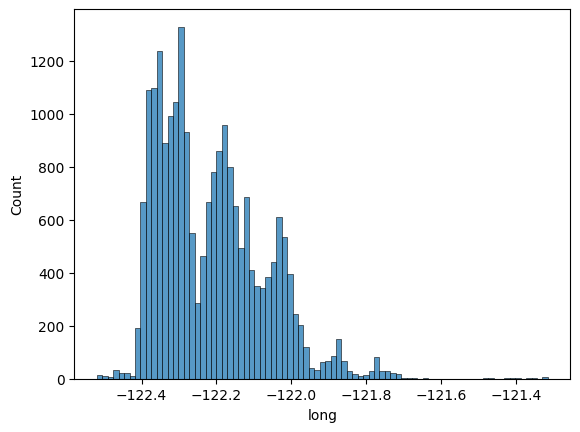

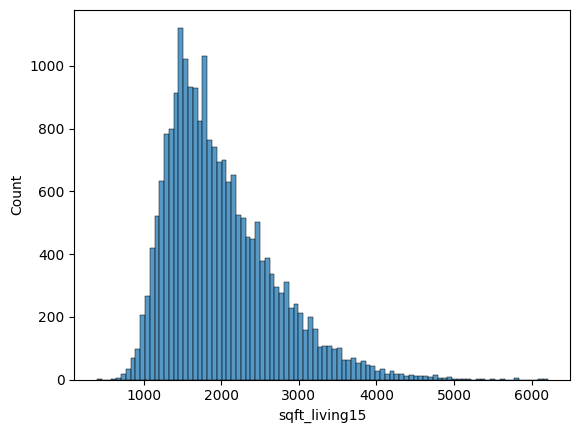

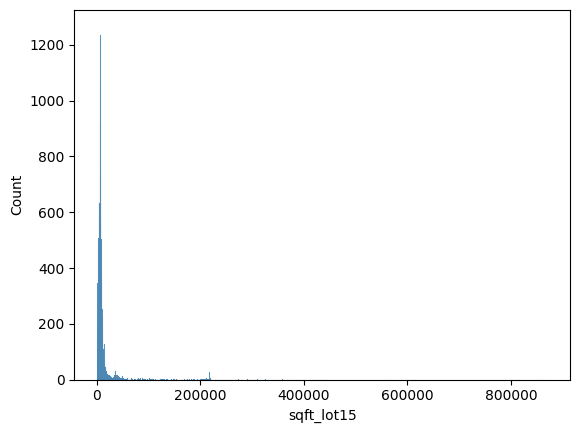

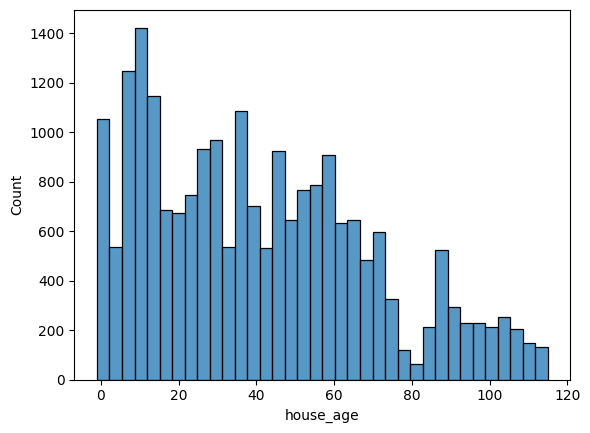

In [ ]:
for i in house_dfl.columns:
  sns.histplot(house_dfl[i])  # los histogramas de todas las columnas
  plt.show()

Focalizamos en la correlación de precio y metros cuadrados:

<ipython-input-61-28e2701e894b>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(house_dfl['price'], ax=axes[0])


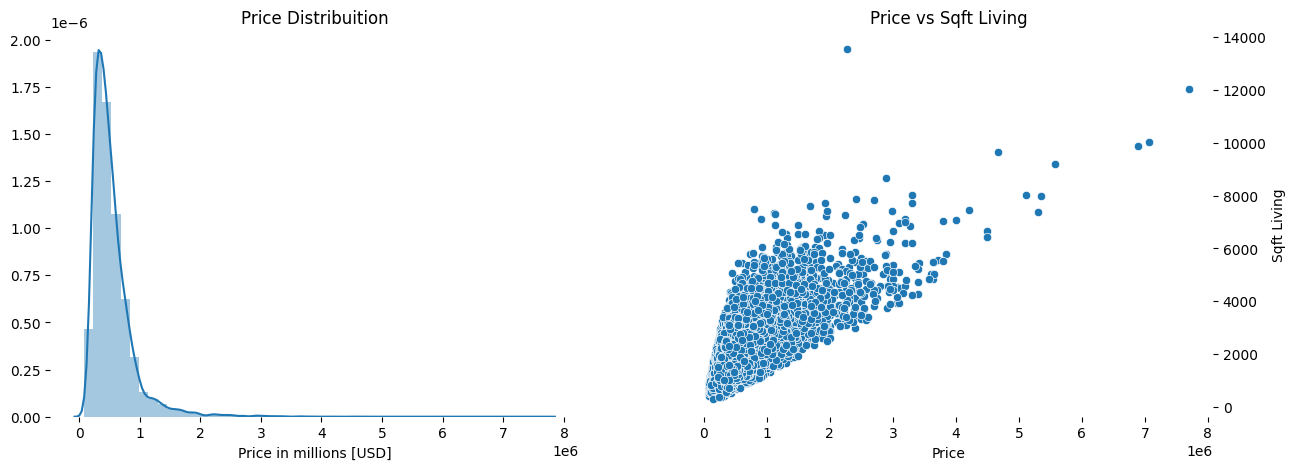

In [ ]:
f, axes = plt.subplots(1, 2,figsize=(15,5))
sns.distplot(house_dfl['price'], ax=axes[0])
sns.scatterplot(x='price',y='sqft_living', data=house_dfl, ax=axes[1])
sns.despine(bottom=True, left=True)
axes[0].set(xlabel='Price in millions [USD]', ylabel='', title='Price Distribuition')
axes[1].set(xlabel='Price', ylabel='Sqft Living', title='Price vs Sqft Living')
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

###Heatmap.

[Heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html), grafica una grilla rectangular de colores asociadas a valores. En nuestro caso la usamos para calcular todos los pares de correlaciones entre las distintas columnas del dataset (matríz de correlación).

La [correlación](https://en.wikipedia.org/wiki/Correlation)  indica una dependencia **lineal** entre variables, cuando una crece la otra crece (o decrece), tomando el valor 1 (o -1) como límite. Un valor cercano a 0 de la correlación indica que no hay asociación lineal entre las variables (lo cual no implica que no haya otra asociación no lineal!).


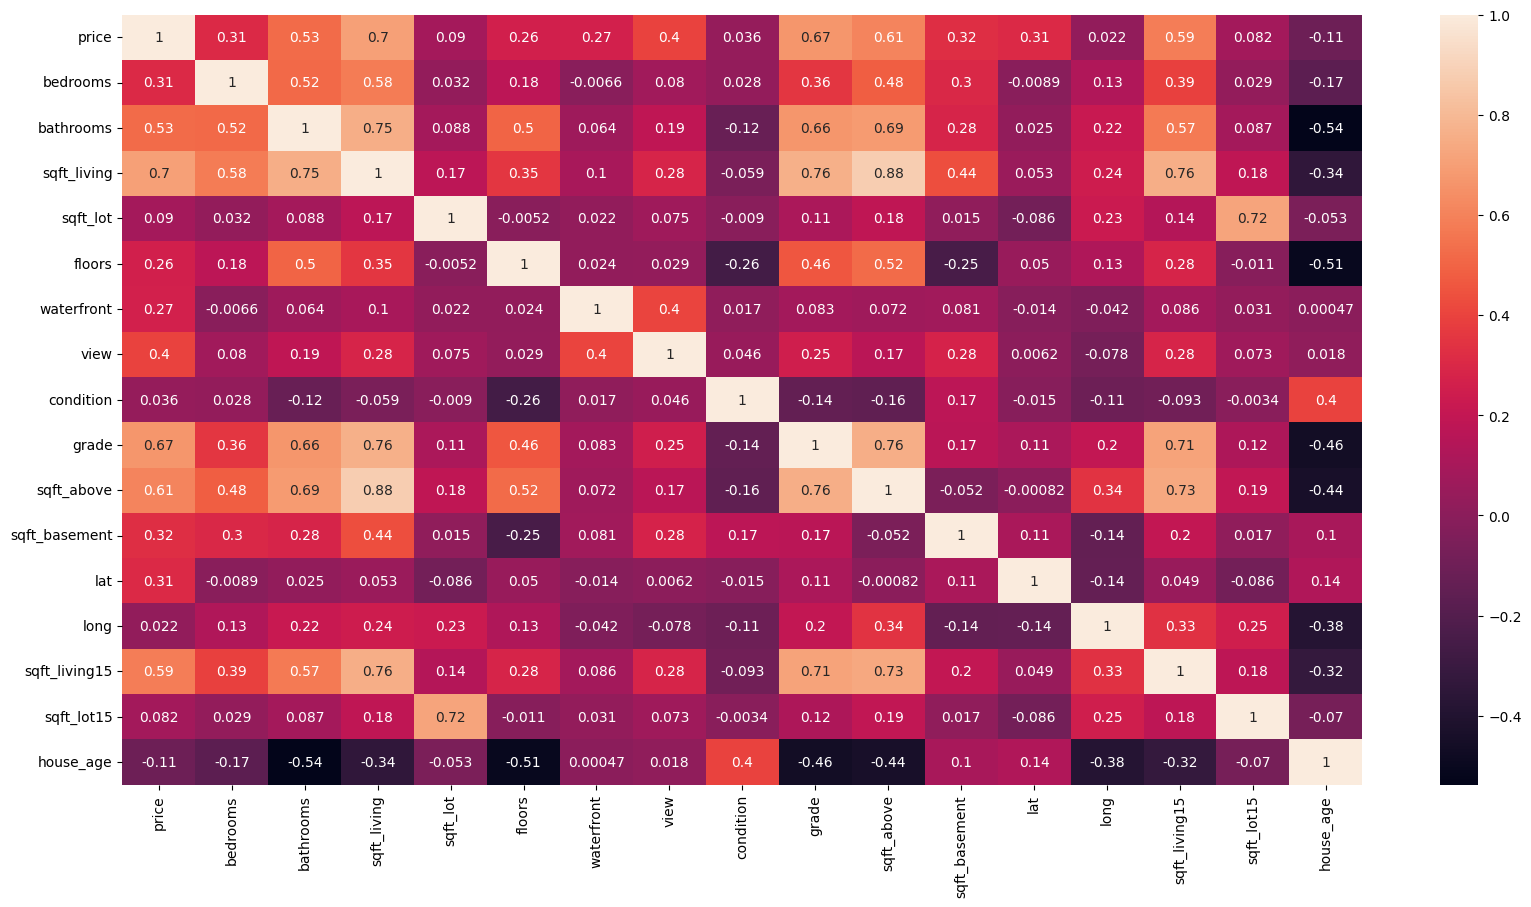

In [ ]:
plt.figure(figsize = (20,10))
sns.heatmap(house_dfl.corr(), annot = True)
plt.show()

En la diagonal está la correlación de la variable consigo misma (1). Los valores en cada casillero (junto con el color) indican el grado de asociadón lineal positiva o negativa de cada par.

Por ejemplo, a partir de la tabla puede verse cómo se asocía el número de baños con la edad de la casa o el precio con los metros cuadrados del living.



###Outliears
Los ouliers son datos que consideraremos "sospechamente" no representativos del conjunto.

Una forma de hacerlo es mediante Boxplots. Éstos son una forma compacta de mostrar la distribución de un conjunto de datos, en la figura siguiente se observan los elementos principales:

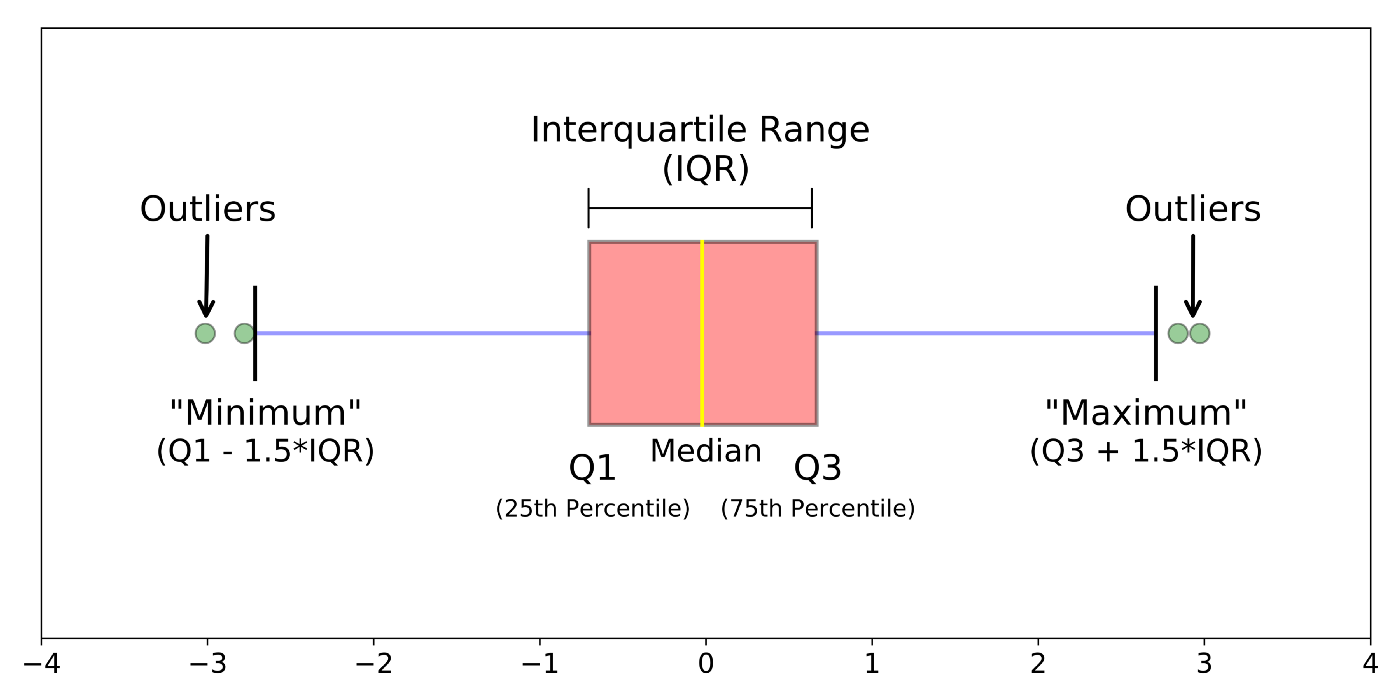





En la figura de arriba, la línea amarilla indica la mediana (divide los datos en dos mitades iguales), la caja rosa encierra el 50 % de los datos (entre los cuartiles $Q_1$ y $Q_3$). El ancho de esta caja se llama rango intercuartil $IQR = Q_3 - Q_1$. Los límites izquierdo y derecho (indicados por dos barras verticales negras) se **definen** como 1.5 veces el ancho de la caja a ambos lados. Los valores que caen fuera de estos límites se consideran outliers (indicados por circulos verdes en la figura).



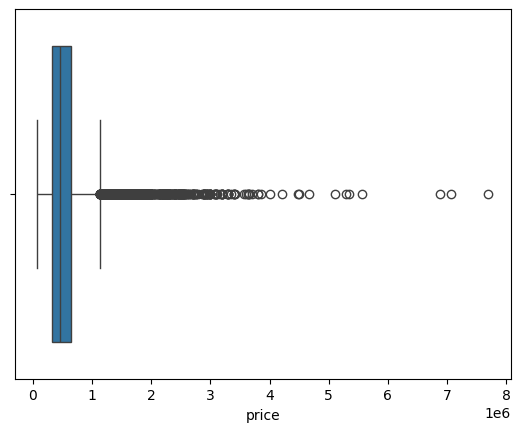

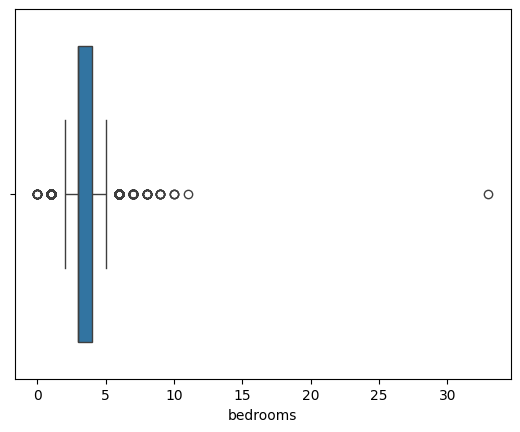

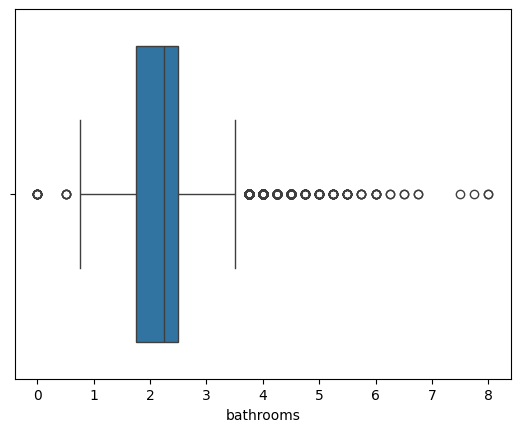

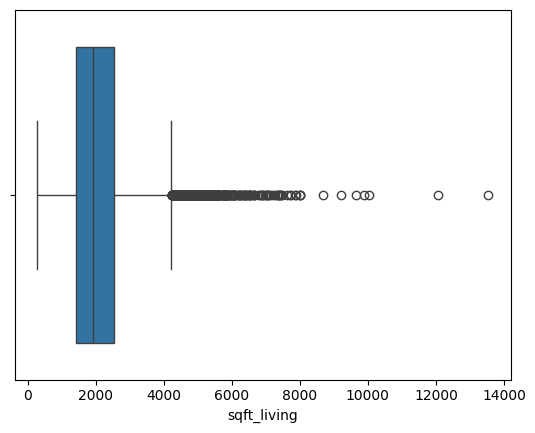

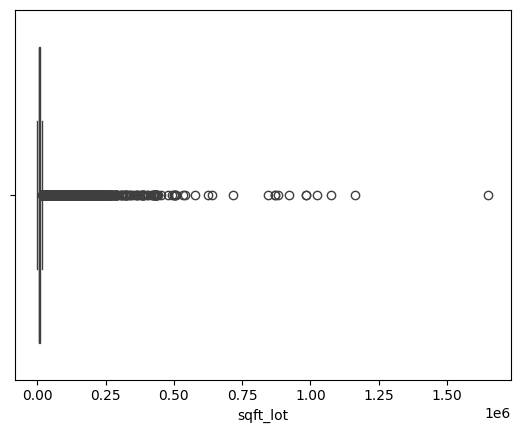

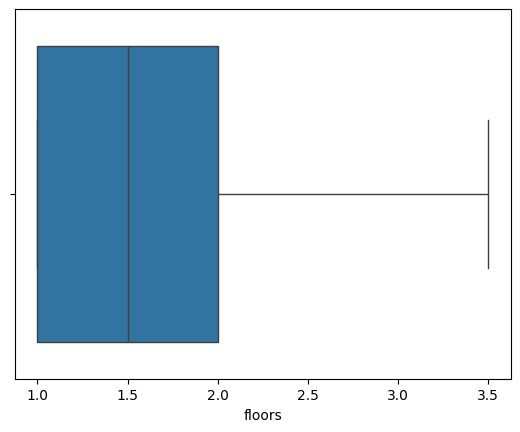

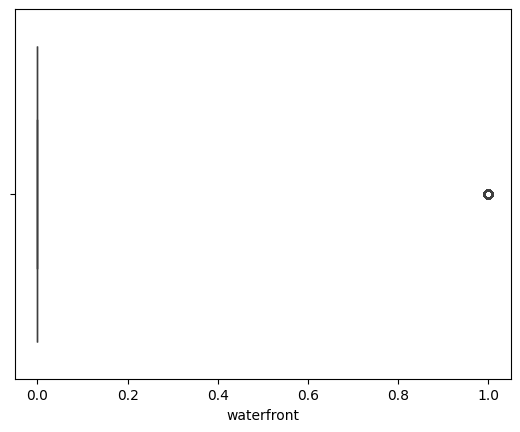

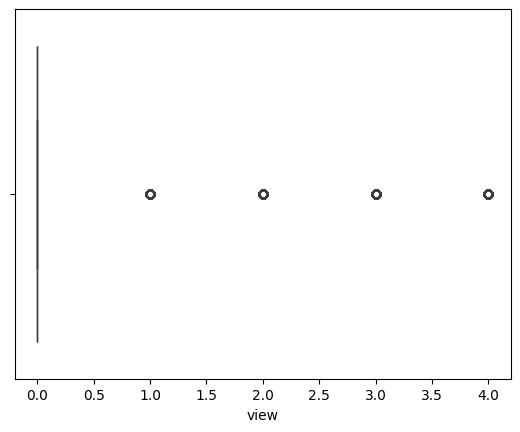

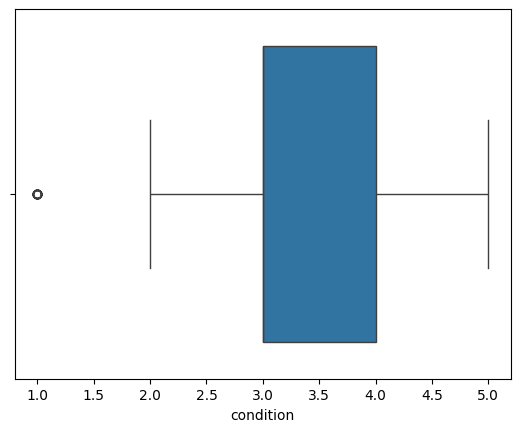

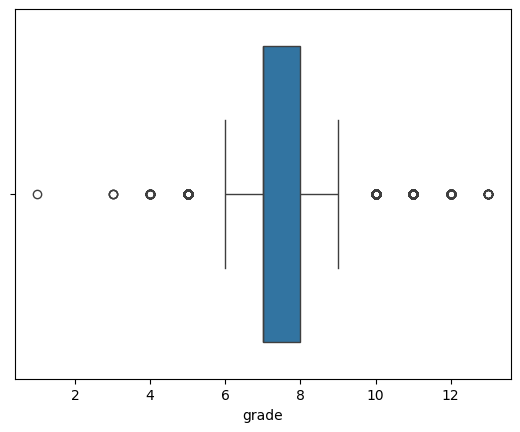

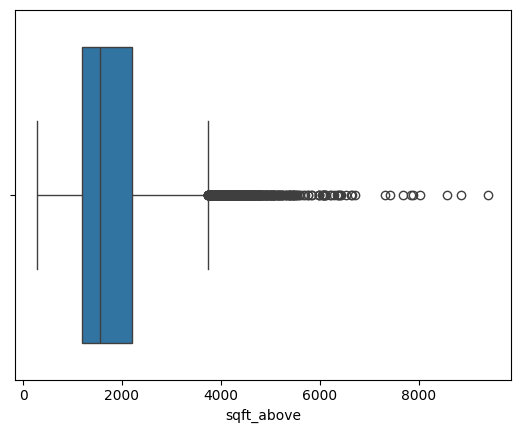

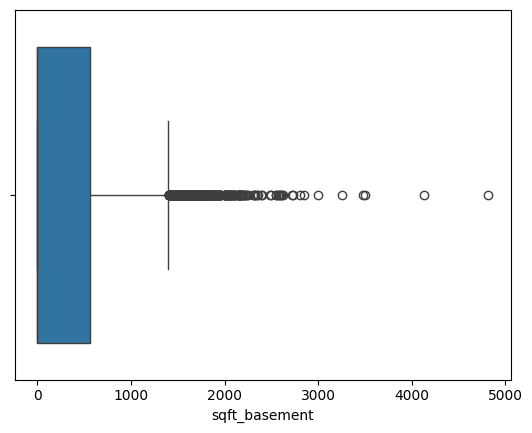

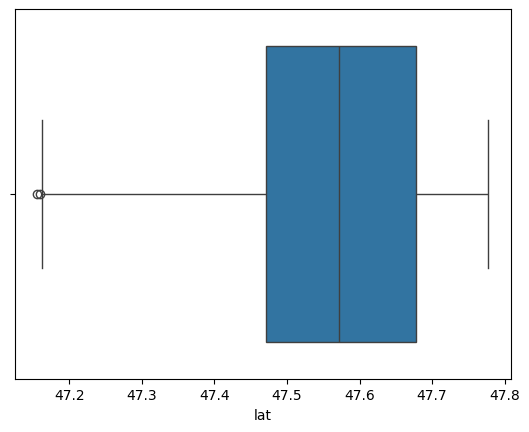

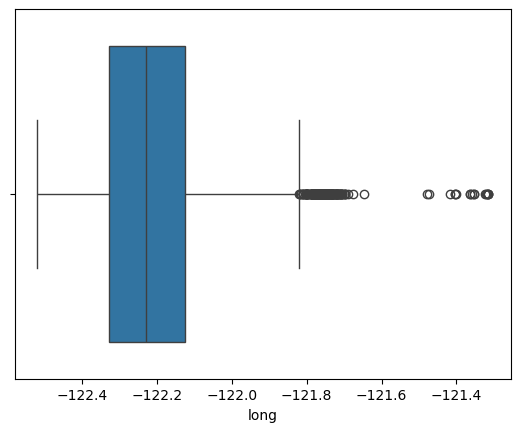

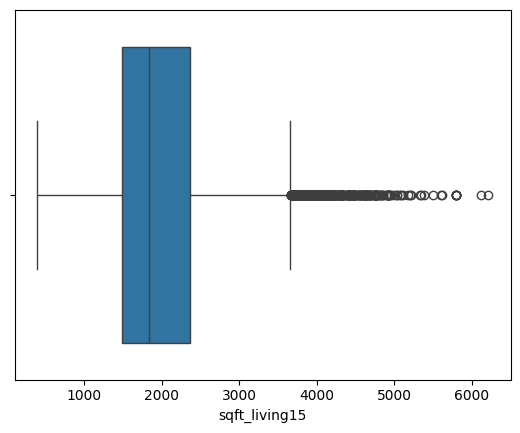

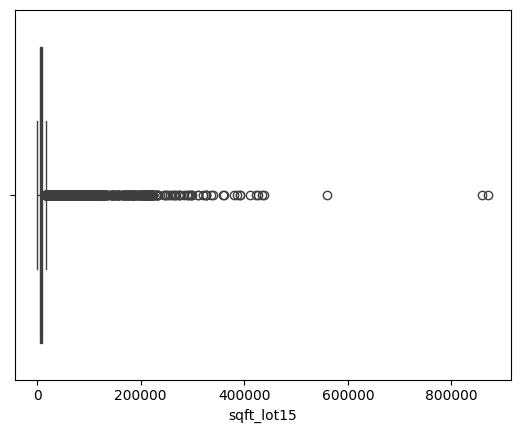

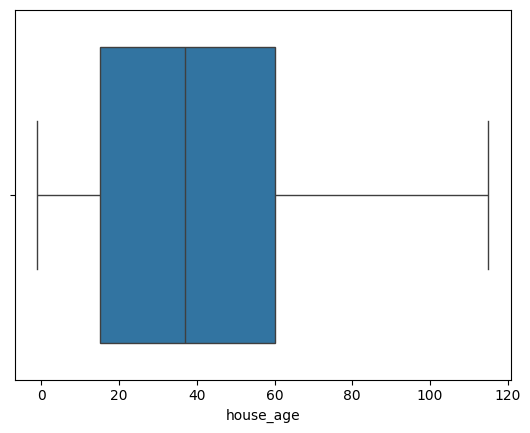

In [ ]:
for i in house_dfl.columns:
  sns.boxplot(x=house_dfl[i])
  plt.show()

Hay muchas cosas para analizar a partir de estos diagramas. Por ejemplo las casas que valen millones o una casa de más de 30 habitaciones  serían oulier.

Para el analisis no eliminamos los ouliers.

## Predicción de precios de casas con una red densa

En esta sección comenzamos a desarrollar el modelo de red en keras para predecir el precio de casas del data analizado.

Comenzamos dividiendo el dataset en input **x**: todas las columnas excepto el precio, y el target **y**: la columna precio



In [ ]:
x = house_dfl.drop('price', axis = 1)
y = house_dfl['price']

In [ ]:
x.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,lat,long,sqft_living15,sqft_lot15,house_age
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,47.5112,-122.257,1340,5650,59.0
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,47.7210,-122.319,1690,7639,23.0
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,47.7379,-122.233,2720,8062,82.0
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,47.5208,-122.393,1360,5000,49.0
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,47.6168,-122.045,1800,7503,28.0


In [ ]:
x.shape

(21613, 16)

In [ ]:
y.shape

(21613,)

Dividimos los datos en train / test usamos la funcionalidad  [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) de [scikit-learn](https://scikit-learn.org/stable/).




In [ ]:
# Split los datos
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.33) #67% train ; 33 % test

Normalizamos los datos restando a cada columna su valor medio y dividiendo por su desviación estándar usando la funcionalidad de scikit-learn.



In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)
print(X_train.mean(), X_train.std())
print(X_test.mean(), X_test.std())

5.604349090390786e-15 1.0
0.0016197362171505789 0.9923856717675875


In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(14480, 16)
(7133, 16)
(14480,)
(7133,)


Ahora definimos un primer modelo.

In [ ]:
#Primer modelo
model = keras.Sequential()
model.add(layers.Dense(64, activation = 'relu'))
model.add(layers.Dense(128, activation = 'relu'))
model.add(layers.Dense(128, activation = 'relu'))
model.add(layers.Dense(64, activation = 'relu'))
model.add(layers.Dense(1))

model.compile(optimizer="rmsprop", loss="mae", metrics=["mse"])

In [ ]:
history = model.fit(x=X_train,y=y_train.values,
          validation_data=(X_test,y_test.values),
          batch_size=20,epochs=100)

Epoch 1/100
724/724 [==============================] - 5s 5ms/step - loss: 275503.3438 - mse: 171345870848.0000 - val_loss: 133261.7656 - val_mse: 51460628480.0000
Epoch 2/100
724/724 [==============================] - 3s 5ms/step - loss: 122233.3359 - mse: 47291297792.0000 - val_loss: 116195.6797 - val_mse: 42494636032.0000
Epoch 3/100
724/724 [==============================] - 2s 3ms/step - loss: 114292.2188 - mse: 43129802752.0000 - val_loss: 112330.9375 - val_mse: 39982407680.0000
Epoch 4/100
724/724 [==============================] - 2s 3ms/step - loss: 111770.1562 - mse: 41861488640.0000 - val_loss: 111363.1562 - val_mse: 36933517312.0000
Epoch 5/100
724/724 [==============================] - 2s 3ms/step - loss: 110447.6094 - mse: 41054445568.0000 - val_loss: 109592.9062 - val_mse: 38140530688.0000
Epoch 6/100
724/724 [==============================] - 3s 4ms/step - loss: 109264.2891 - mse: 40291471360.0000 - val_loss: 108852.5859 - val_mse: 36358868992.0000
Epoch 7/100
724/724 [

Ahora graficamos los resultados para visualizar la evolución del entrenamiento:

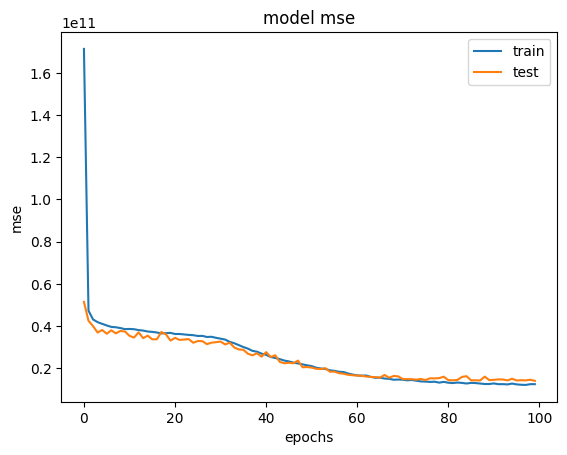

In [ ]:
# plot training
plt.plot(history.history['mse'])
plt.plot(history.history['val_mse'])
plt.title('model mse')
plt.ylabel('mse')
plt.xlabel('epochs')
plt.legend(['train','test'], loc = 'upper right')
plt.show()

In [ ]:
predictions = model.predict(X_test)

print('MAE: ',mean_absolute_error(y_test,predictions))
print('MSE: ',mean_squared_error(y_test,predictions))
print('RMSE: ',np.sqrt(mean_squared_error(y_test,predictions)))
print('Variance Regression Score: ',explained_variance_score(y_test,predictions))

print('\n\nDescriptive Statistics:\n',house_df['price'].describe())

223/223 [==============================] - 0s 2ms/step
MAE:  67515.79878951704
MSE:  14046938240.417675
RMSE:  118519.77995430837
Variance Regression Score:  0.8944400479321064


Descriptive Statistics:
 count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64


**Mean Absolute Error** (MAE) es la media del valor absoluto de los errores:

$$ \frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

donde $y_i$ indica los valores reales (labels) e $\hat{y}_i$ los valores predichos (regresión)   

**Mean Squared Error** (MSE) es la media de los cuadrados de los errores:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Root Mean Squared Error** (RMSE) es la raíz cuadrada de la media de los cuadrados de los errores

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

Comparación de las métricas:

- **MAE** es la más simple de interpretar.

- **MSE** penaliza los errores más grandes, lo que tiende a ser útil en el mundo real.

- **RMSE** más popular que MSE, porque RMSE es interpretable en las unidades "y".

- **$R^2$** es una de las métricas más importantes para analizar la "varianza" capturtada por el modelo.



###Visualización de resultados.

Para visualizar nuestros resultados graficamos el histograma de error y las predicciones contra el y verdadero en test:

<ipython-input-40-22d6bdf08941>:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(errors, ax=axes[0])


[Text(0.5, 0, 'Y Test Verdadero'),
 Text(0, 0.5, 'Prediccion Test Modelo'),
 Text(0.5, 1.0, 'Predicciones Modelo vs Predicción Perfecta')]

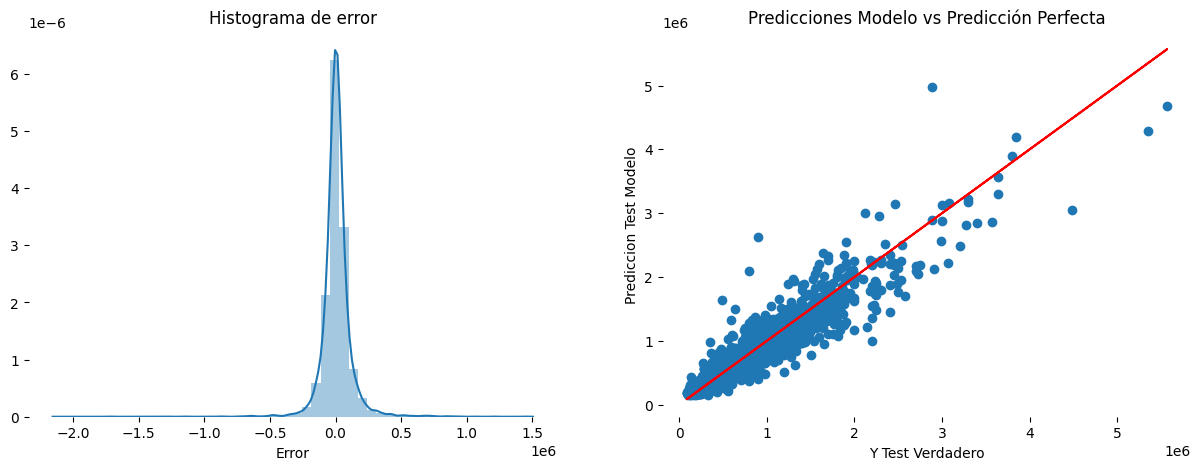

In [ ]:
f, axes = plt.subplots(1, 2,figsize=(15,5))

# la predicción del modelo.
plt.scatter(y_test,predictions)

# predicción ideal.
plt.plot(y_test,y_test,'r')

errors = y_test.values.reshape(7133, 1) - predictions
sns.distplot(errors, ax=axes[0])

sns.despine(left=True, bottom=True)
axes[0].set(xlabel='Error', ylabel='', title='Histograma de error')
axes[1].set(xlabel='Y Test Verdadero', ylabel='Prediccion Test Modelo', title='Predicciones Modelo vs Predicción Perfecta')


**Analisis:**
- La línea roja a 45º de la derecha indica el caso ideal de predicción perfecta.
- Los puntos azules localizan la predicción vs el valor verdadero.
- Puntos cercanos a la línea roja son buenas predicciones.

